# Demo for Bi-fidelity Stochastic Subspace Descent

In [19]:
from wrapper import *
import numpy as np
import matplotlib.pyplot as plt

In [20]:
def f_lr(x, lbd, r):
    if r > len(x):
        raise ValueError('r must be less than or equal to the length of x')
    sums = (x[0]**2 + sum((x[i] - x[i+1])**2 for i in range(0, r-1)) + x[r-1]**2)/2 - x[0]# + 1e-3 * sum(x[i]**2 for i in range(r, len(x)))
    return lbd * sums/4 + 0.12

f    = lambda x : f_lr(x, 1, 10)
f_LF = lambda x : f_lr(x, 1, 5)
x0  = np.random.randn(20)

obj = objectiveFcn(f,label='Low-rank Function')
obj_lowFi= objectiveFcn(f_LF)

# initial point
d = 20
x0 = np.random.randn(d)
learning_rate = 1e-2
ell = 5
num_iterations = 20
learning_rate_ssd = learning_rate*ell/3

In [ ]:
from tqdm import tqdm
num_trials = 10
gd, cd, ssdd, ssdd_ls, ssdd_ls_cal = [], [], [], [], []
for i in tqdm(range(num_trials)):
    # Gradient Descent
    _ = grad_desc(x0,obj,learning_rate=learning_rate,num_iterations=num_iterations)
    gd.append(obj.returnHistory())
    # Coordinate Descent
    _ = coor_desc(x0,obj,learning_rate=learning_rate,num_iterations=num_iterations/2)
    cd.append(obj.returnHistory())
    # SSD
    _ = ssd(x0,obj,ell=ell,learning_rate=learning_rate_ssd,num_iterations=num_iterations*d/ell)
    ssdd.append(obj.returnHistory())
    # SSD with linesearch (LF)
    _ = ssd_ls(x0,obj,ell=ell,learning_rate=learning_rate_ssd, obj_lowFi= obj_lowFi,
                num_iterations=num_iterations*d/ell, linesearchIter=10 )
    ssdd_ls.append(obj.returnHistory())
    # SSD with linesearch (BF)
    _ = ssd_ls(x0,obj,ell=ell,learning_rate=learning_rate_ssd, obj_lowFi= obj_lowFi,
               num_iterations=num_iterations*d/ell, linesearchIter=10, calibrated=True )
    ssdd_ls_cal.append(obj.returnHistory())
gd, cd, ssd, ssd_ls, ssd_ls_cal = np.asarray(gd), np.asarray(cd), np.asarray(ssd), np.asarray(ssd_ls), np.asarray(ssd_ls_cal)

In [ ]:
# # Uncomment to load results
# file = np.load('demo_res.npz')
# gd, cd, ssdd, ssdd_ls, ssdd_ls_cal = file['gd'], file['cd'], file['ssd'], file['ssd_ls'], file['ssd_ls_cal']

In [40]:
gd, cd, ssdd, ssdd_ls, ssdd_ls_cal = np.asarray(gd), np.asarray(cd), np.asarray(ssdd), np.asarray(ssdd_ls), np.asarray(ssdd_ls_cal)
gd_mean, gd_std = np.mean(gd[:,10:400], axis=0), np.std(gd[:,10:400], axis=0)
cd_mean, cd_std = np.mean(cd[:,10:400], axis=0), np.std(cd[:,10:400], axis=0)
ssd_mean, ssd_std = np.mean(ssdd[:,10:400], axis=0), np.std(ssdd[:,10:400], axis=0)
ssd_ls_mean, ssd_ls_std = np.mean(ssdd_ls[:,10:400], axis=0), np.std(ssdd_ls[:,10:400], axis=0)
ssd_ls_cal_mean, ssd_ls_cal_std = np.mean(ssdd_ls_cal[:,10:400], axis=0), np.std(ssdd_ls_cal[:,10:400], axis=0)

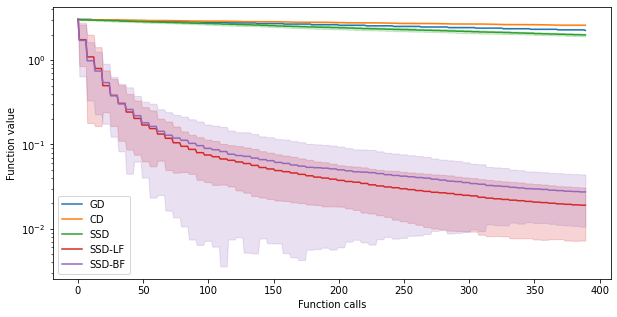

In [43]:
plt.figure(figsize=(10,5))
plt.plot(gd_mean, label='GD', color='tab:blue')
plt.fill_between(range(len(gd_mean)), gd_mean-1.94*gd_std, gd_mean+1.94*gd_std, alpha=0.2, color='tab:blue')
plt.plot(cd_mean, label='CD', color='tab:orange')
plt.fill_between(range(len(cd_mean)), cd_mean-1.94*cd_std, cd_mean+1.94*cd_std, alpha=0.2, color='tab:orange')
plt.plot(ssd_mean, label='SSD', color='tab:green')
plt.fill_between(range(len(ssd_mean)), ssd_mean-1.94*ssd_std, ssd_mean+1.94*ssd_std, alpha=0.2, color='tab:green')
plt.plot(ssd_ls_mean, label='SSD-LF', color='tab:red')
plt.fill_between(range(len(ssd_ls_mean)), ssd_ls_mean-1.94*ssd_ls_std, ssd_ls_mean+1.94*ssd_ls_std, alpha=0.2, color='tab:red')
plt.plot(ssd_ls_cal_mean, label='SSD-BF', color='tab:purple')
plt.fill_between(range(len(ssd_ls_cal_mean)), ssd_ls_cal_mean-1.94*ssd_ls_cal_std, ssd_ls_cal_mean+1.94*ssd_ls_cal_std, alpha=0.2, color='tab:purple')
plt.yscale('log')
plt.xlabel('Function calls'), plt.ylabel('Function value'), plt.legend()
plt.show()

In [24]:
# plt.semilogy(fcnHist_gradDesc[10:], label='Finite Diff. Gradient Descent')
# plt.semilogy(fcnHist_coorDesc[10:], label='Finite Diff. Coordinate Descent')
# plt.semilogy(fcnHist_ssd[10:], label=f'ssd, ell={ell}')
# plt.semilogy(fcnHist_ssd_linesearch[10:], label=f'ssd, ell={ell} w/ low-fi linesearch')
# plt.semilogy(fcnHist_ssd_linesearch_cal[10:], label=f'ssd, ell={ell} w/ bi-fi linesearch')
# plt.title(obj.label)
# plt.xlabel('Function calls'), plt.ylabel('Function value'), plt.legend()